## PlantVillage 


### Yêu cầu
- Phân tích dữ liệu 
- Cân bằng dữ liệu
- Xây dựng mô hình CNN thuần bằng PyTorch
- Huấn luyện và đánh giá mô hình
- Hạn chế overfitting

# 1. Import thư viện

In [1]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset

import torchvision
from torchvision import datasets, transforms
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 2. Thiết lập seed để kết quả ổn định hơn

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị đang dùng:", device)

Thiết bị đang dùng: cpu


# 3. Khai báo đường dẫn dữ liệu

In [3]:
# Sửa lại đường dẫn này cho đúng với thư mục PlantVillage trên máy/Colab của bạn
dataset_path = "./data/PlantVillage"

print("Đường dẫn hiện tại:", dataset_path)
print("Tồn tại hay không:", os.path.exists(dataset_path))

Đường dẫn hiện tại: ./data/PlantVillage
Tồn tại hay không: True


# 4. Transform cho tập train và validation/test

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 5. Tải dataset gốc để xem thông tin ban đầu

In [5]:
full_dataset_for_info = datasets.ImageFolder(root=dataset_path)

class_names = full_dataset_for_info.classes
num_classes = len(class_names)

# Khởi tạo model
model = PlantVillage_CNN(num_classes=num_classes).to(device)

print("Số lớp:", num_classes)
print("Tên các lớp:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Tổng số ảnh:", len(full_dataset_for_info))

Số lớp: 16
Tên các lớp:
0: Pepper__bell___Bacterial_spot
1: Pepper__bell___healthy
2: PlantVillage
3: Potato___Early_blight
4: Potato___Late_blight
5: Potato___healthy
6: Tomato_Bacterial_spot
7: Tomato_Early_blight
8: Tomato_Late_blight
9: Tomato_Leaf_Mold
10: Tomato_Septoria_leaf_spot
11: Tomato_Spider_mites_Two_spotted_spider_mite
12: Tomato__Target_Spot
13: Tomato__Tomato_YellowLeaf__Curl_Virus
14: Tomato__Tomato_mosaic_virus
15: Tomato_healthy
Tổng số ảnh: 41276


# 6. Phân tích phân bố số lượng ảnh theo lớp (EDA)

Số ảnh theo từng lớp:
Pepper__bell___Bacterial_spot: 997
Pepper__bell___healthy: 1478
PlantVillage: 20638
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1909
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208
Tomato__Tomato_mosaic_virus: 373
Tomato_healthy: 1591


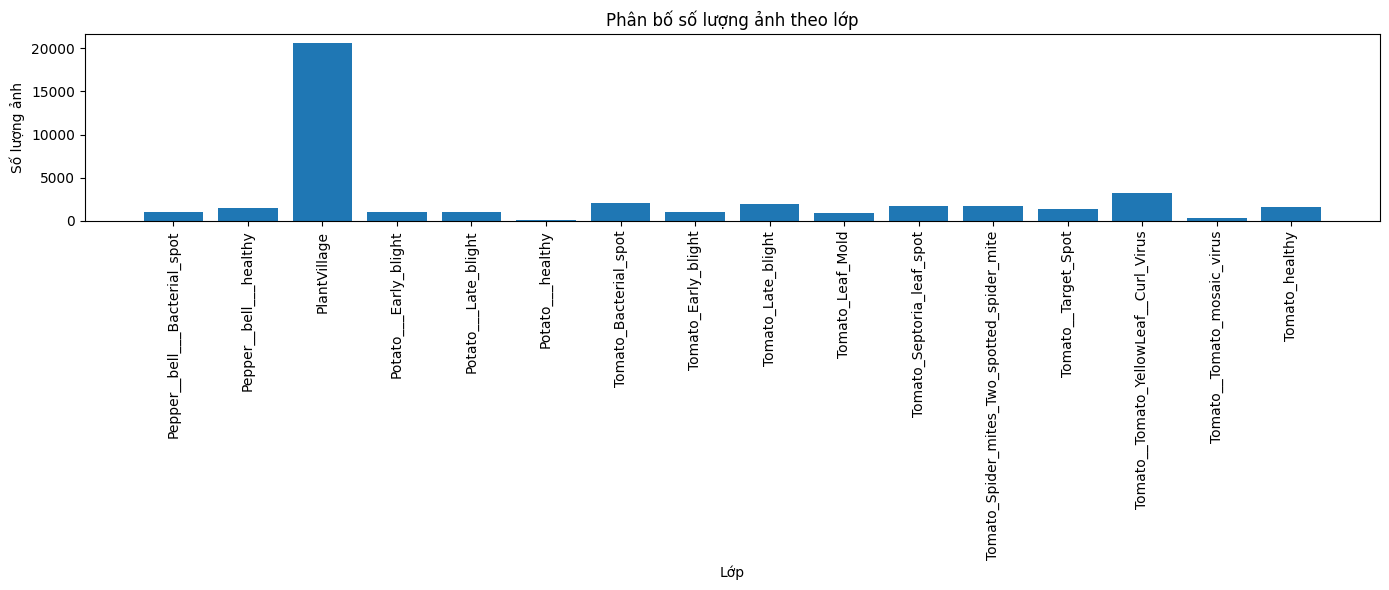

In [6]:
labels = [label for _, label in full_dataset_for_info.samples]
class_counts = Counter(labels)

print("Số ảnh theo từng lớp:")
for class_idx, count in class_counts.items():
    print(f"{class_names[class_idx]}: {count}")

plt.figure(figsize=(14, 6))
plt.bar([class_names[i] for i in range(num_classes)],
        [class_counts[i] for i in range(num_classes)])
plt.xticks(rotation=90)
plt.title("Phân bố số lượng ảnh theo lớp")
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.tight_layout()
plt.show()

# 7. Hiển thị một vài ảnh mẫu của dataset

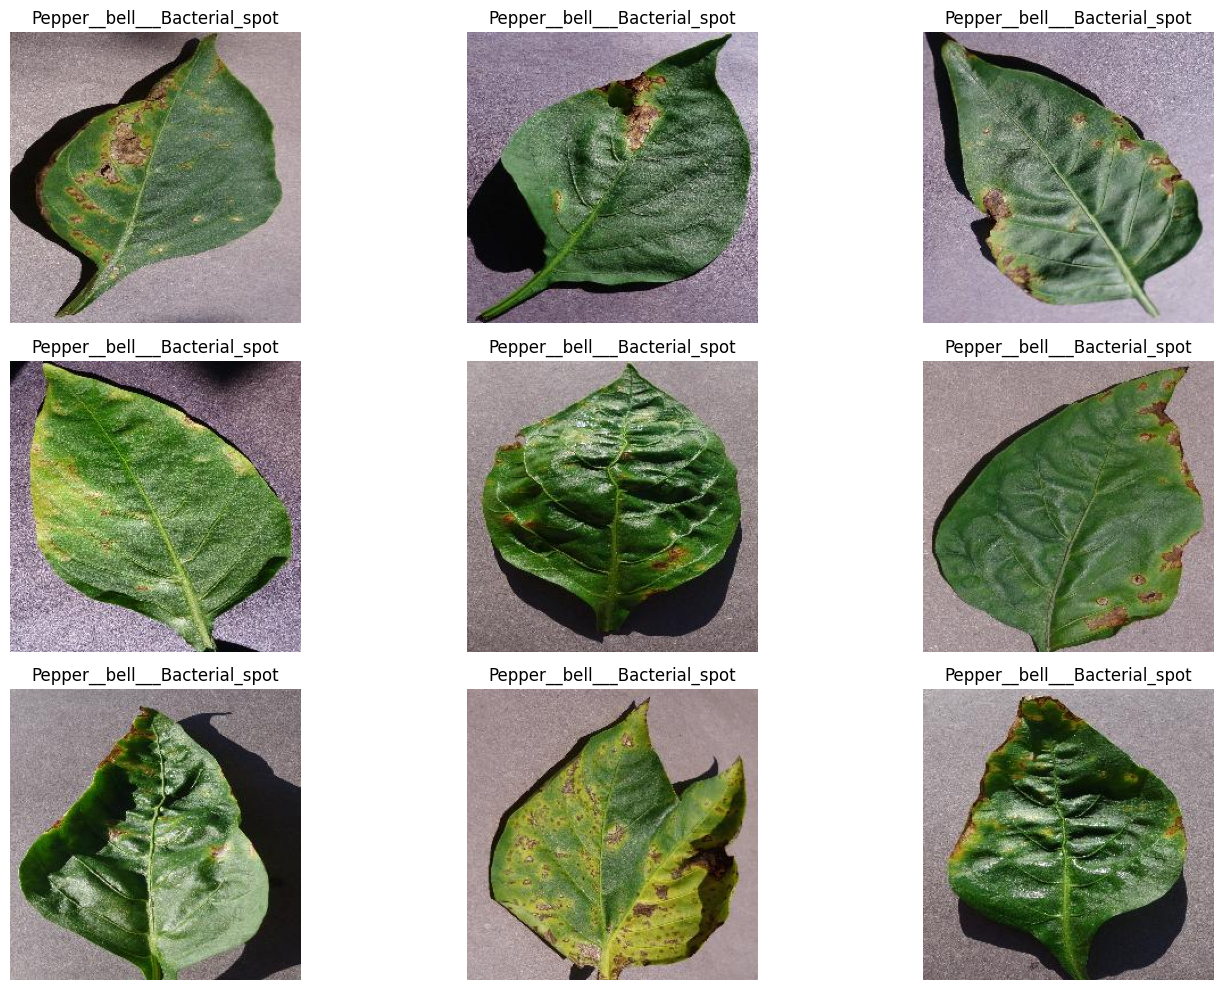

In [7]:
plt.figure(figsize=(15, 10))
for i in range(min(num_classes, 9)):
    img_path, label = full_dataset_for_info.samples[i]
    img = plt.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8. Tạo 2 dataset riêng

In [8]:
# 1 dataset cho train với train_transform
# 1 dataset cho validation/test với test_transform
full_dataset_train_tf = datasets.ImageFolder(root=dataset_path, transform=train_transform)
full_dataset_test_tf  = datasets.ImageFolder(root=dataset_path, transform=test_transform)

dataset_size = len(full_dataset_train_tf)
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

indices = list(range(dataset_size))
random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = Subset(full_dataset_train_tf, train_indices)
val_dataset   = Subset(full_dataset_test_tf, val_indices)
test_dataset  = Subset(full_dataset_test_tf, test_indices)

print("Số ảnh train     :", len(train_dataset))
print("Số ảnh validation:", len(val_dataset))
print("Số ảnh test      :", len(test_dataset))

Số ảnh train     : 33020
Số ảnh validation: 4127
Số ảnh test      : 4129


# 9. Tạo WeightedRandomSampler để cân bằng dữ liệu cho tập train

In [9]:
train_labels = [full_dataset_train_tf.samples[i][1] for i in train_indices]
train_class_counts = Counter(train_labels)

class_weights = {cls: 1.0 / count for cls, count in train_class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Đã tạo sampler để hỗ trợ cân bằng dữ liệu.")

Đã tạo sampler để hỗ trợ cân bằng dữ liệu.


# 10. Tạo DataLoader

In [10]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Số batch train:", len(train_loader))
print("Số batch validation:", len(val_loader))
print("Số batch test:", len(test_loader))

Số batch train: 1032
Số batch validation: 129
Số batch test: 130


# 11. Định nghĩa mô hình CNN cho PlantVillage

In [16]:
class PlantVillage_CNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantVillage_CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = PlantVillage_CNN(num_classes=num_classes).to(device)
print(model)

PlantVillage_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [17]:
# Khởi tạo model
model = PlantVillage_CNN(num_classes=num_classes).to(device)

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

# Scheduler (giảm learning rate khi val_acc không tăng)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

print("Model + optimizer đã sẵn sàng")

Model + optimizer đã sẵn sàng


# 13. Huấn luyện mô hình

In [18]:
num_epochs = 10
patience = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0.0
trigger_times = 0
best_model_path = "best_plantvillage_cnn.pth"

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct / total

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc*100:.2f}% - "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Dừng sớm để tránh overfitting.")
            break


Epoch [1/10] - Train Loss: 1.4859 - Train Acc: 52.90% - Val Loss: 1.8018 - Val Acc: 41.48%
Epoch [2/10] - Train Loss: 0.9606 - Train Acc: 69.73% - Val Loss: 1.7295 - Val Acc: 44.85%
Epoch [3/10] - Train Loss: 0.8284 - Train Acc: 74.22% - Val Loss: 1.6791 - Val Acc: 47.08%
Epoch [4/10] - Train Loss: 0.7418 - Train Acc: 76.76% - Val Loss: 1.6031 - Val Acc: 47.90%
Epoch [5/10] - Train Loss: 0.6714 - Train Acc: 79.45% - Val Loss: 1.5387 - Val Acc: 48.19%
Epoch [6/10] - Train Loss: 0.6403 - Train Acc: 80.27% - Val Loss: 1.5370 - Val Acc: 47.15%
Epoch [7/10] - Train Loss: 0.5925 - Train Acc: 81.95% - Val Loss: 1.6144 - Val Acc: 47.88%
Epoch [8/10] - Train Loss: 0.5516 - Train Acc: 83.33% - Val Loss: 1.6522 - Val Acc: 48.51%
Epoch [9/10] - Train Loss: 0.5286 - Train Acc: 83.93% - Val Loss: 1.4847 - Val Acc: 48.46%
Epoch [10/10] - Train Loss: 0.4968 - Train Acc: 85.20% - Val Loss: 1.6520 - Val Acc: 48.92%


# 14. Vẽ biểu đồ loss và accuracy

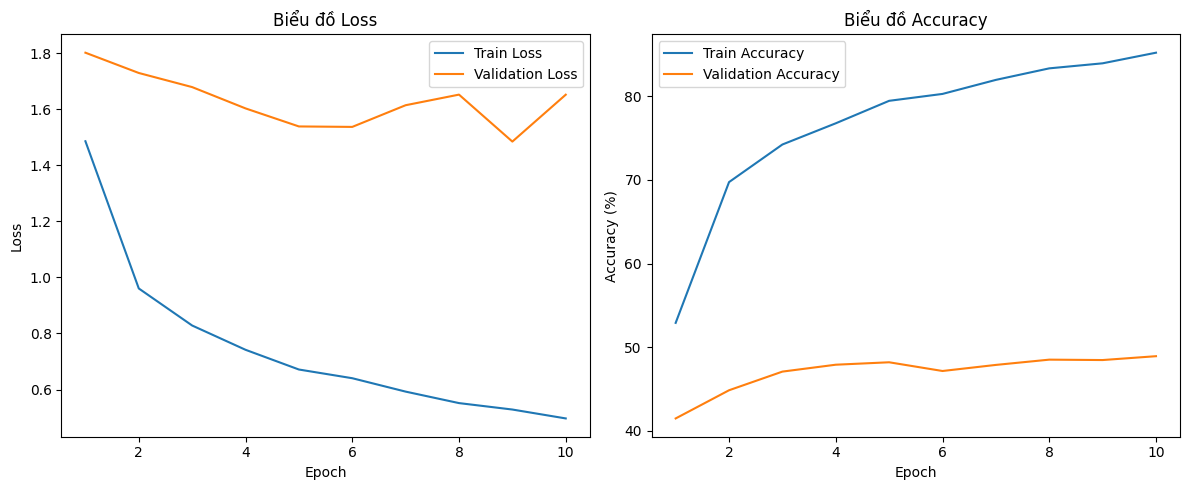

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Biểu đồ Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), [acc * 100 for acc in train_accuracies], label="Train Accuracy")
plt.plot(range(1, len(val_accuracies) + 1), [acc * 100 for acc in val_accuracies], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Biểu đồ Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 15. Đánh giá mô hình trên tập test

In [21]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total
print(f"Độ chính xác trên tập test: {test_acc*100:.2f}%")

Độ chính xác trên tập test: 48.00%


# 16. Ma trận nhầm lẫn

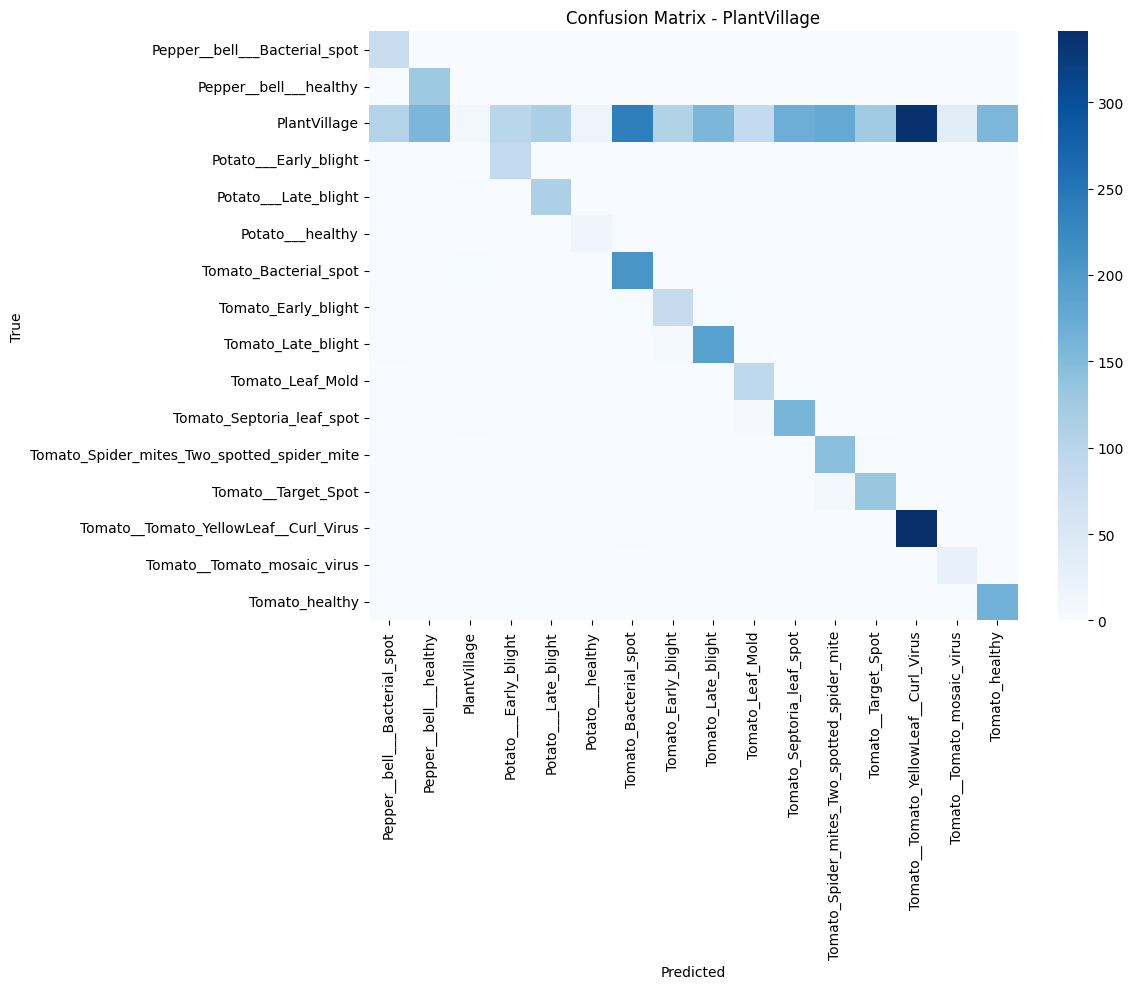

In [22]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - PlantVillage")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 17. Báo cáo phân loại

In [23]:
print(classification_report(all_labels, all_preds, target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.42      0.98      0.59        82
                     Pepper__bell___healthy       0.45      0.99      0.62       130
                               PlantVillage       0.50      0.01      0.01      2093
                      Potato___Early_blight       0.47      0.98      0.64        91
                       Potato___Late_blight       0.50      0.97      0.66       116
                           Potato___healthy       0.45      1.00      0.62        15
                      Tomato_Bacterial_spot       0.46      0.99      0.63       210
                        Tomato_Early_blight       0.42      0.86      0.56        98
                         Tomato_Late_blight       0.54      0.94      0.69       202
                           Tomato_Leaf_Mold       0.50      1.00      0.67        94
                  Tomato_Septoria_leaf_spot       0.48      0.94

## Nhận xét

Bộ dữ liệu PlantVillage có số lượng lớp lớn (nhiều loại bệnh lá cây khác nhau) và độ phức tạp cao hơn so với hai dataset còn lại. Hình ảnh có kích thước lớn hơn và đa dạng hơn về màu sắc, kết cấu và đặc trưng bệnh.

Kết quả huấn luyện cho thấy:
- train accuracy tăng đều (từ ~52% lên ~85%)

- validation accuracy duy trì thấp (~49%)

Điều này cho thấy mô hình học tốt trên tập huấn luyện nhưng không tổng quát hóa tốt trên tập validation, biểu hiện rõ của hiện tượng overfitting.

Nguyên nhân có thể bao gồm:

- số lượng lớp lớn dẫn đến bài toán khó hơn

- dữ liệu giữa train và validation chưa cân bằng tốt

- thời gian huấn luyện còn hạn chế (10 epoch)

mô hình CNN thuần chưa đủ mạnh để học đặc trưng phức tạp